<a href="https://colab.research.google.com/github/Rashish1/AI-Ml_projects/blob/main/Domain_Price_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import time

Acquiring data

In [ ]:
df = pd.read_csv('/Users/admin/Documents/UEL/CN7050 Intelligent Systems/DomainData.csv')

Data/Feature Extraction and Selection

In [ ]:
def numerals_count(domain):
  return sum(c.isdigit() for c in domain)

def letters_count(domain):
  domain = domain.split('.')[0]
  return sum(c.isalpha() for c in domain)

def special_characters_count(domain):
  domain = domain.split('.')[0]
  return sum(not c.isalnum() for c in domain)

def length(domain):
  domain = domain.split('.')[0]
  return len(domain)

def has_dot(domain):
  rdomain = domain.split('.')[0]
  return 1 if '.' in rdomain else 0

def has_underscore(domain):
  rdomain = domain.split('.')[0]
  return 1 if '_' in rdomain else 0

def starts_with_digit(domain):
  rdomain = domain.split('.')[0]
  return 1 if rdomain[0].isdigit() else 0

def ends_with_digit(domain):
  rdomain = domain.split('.')[0]
  return 1 if rdomain[-1].isdigit() else 0

def has_consecutive_digits(domain):
  rdomain = domain.split('.')[0]
  return 1 if re.search(r'\d{2,}', rdomain) else 0

def has_unique_characters(domain):
  rdomain = domain.split('.')[0]
  return 1 if len(set(rdomain)) == len(rdomain) else 0

def load_common_words(filepath):
  with open(filepath, 'r') as file:
    return set(word.strip().lower() for word in file)

def is_suspicious_tld(tld):
  suspicious_tlds = [
      'country',
      'kim',
      'science',
      'gq',
      'work',
      'ninja',
      'xyz',
      'date',
      'faith',
      'zip',
      'racing',
      'cricket',
      'win',
      'space',
      'accountant',
      'realtor',
      'top',
      'stream',
      'christmas',
      'gdn',
      'mom',
      'pro',
      'men']
  return 1 if tld in suspicious_tlds else 0

def has_homoglyphics(domain):
  return 1 if re.search(r'[01lo]', domain) else 0

# Function to find all possible words in a domain
def find_all_words_in_domain(domain, common_words):
  # Remove TLD and split domain into parts
  domain_without_tld = domain.rsplit('.', 1)[0]

  words_found = set()  # Use a set to avoid duplicates

  # Search for words starting from each character in the domain
  for start_index in range(len(domain_without_tld)):
    for end_index in range(start_index + 1, len(domain_without_tld) + 1):
      substring = domain_without_tld[start_index:end_index].lower()
      if substring in common_words:
        words_found.add(substring)

  return list(words_found)  # Convert set to list for consistency

In [ ]:
def extract_features(df):
  df['tld'] = df['Domain'].apply(lambda x: x.split('.')[-1])
  df['numerals'] = df['Domain'].apply(numerals_count)
  df['letters'] = df['Domain'].apply(letters_count)
  df['special_char'] = df['Domain'].apply(special_characters_count)
  df['length'] = df['Domain'].apply(length)
  df['alpha_num_ratio'] = df['Domain'].apply(lambda x: sum(c.isalpha() for c in x) / sum(c.isalnum() for c in x))
  df['num_vowels'] = df['Domain'].apply(lambda x: sum(1 for c in x if c.lower() in 'aeiou'))
  df['num_consonants'] = df['Domain'].apply(lambda x: sum(1 for c in x if c.isalpha() and c.lower() not in 'aeiou'))
  df['vowel_consonant_ratio'] = df['num_vowels'] / df['num_consonants']
  df['num_digits'] = df['Domain'].apply(lambda x: sum(1 for c in x if c.isdigit()))
  df['has_hyphen'] = df['Domain'].apply(lambda x: '-' in x)
  df['has_underscore'] = df['Domain'].apply(has_underscore)
  df['has_dot'] = df['Domain'].apply(has_dot)
  df['starts_with_digit'] = df['Domain'].apply(starts_with_digit)
  df['ends_with_digit'] = df['Domain'].apply(ends_with_digit)
  df['has_consecutive_digits'] = df['Domain'].apply(has_consecutive_digits)
  df['has_unique_characters'] = df['Domain'].apply(has_unique_characters)
  df['num_unique_characters'] = df['Domain'].apply(lambda x: len(set(x)))
  df['has_homoglyphics'] = df['Domain'].apply(has_homoglyphics)
  df['is_suspicious_tld'] = df['tld'].apply(is_suspicious_tld)

  common_words = load_common_words('/Users/admin/Documents/UEL/CN7050 Intelligent Systems/Reference Data/HelpfulData/EnlgishMostCommonwords.txt')
  word_counts = []
  for domain in df['Domain']:
      words = find_all_words_in_domain(domain, common_words)
      word_counts.append(len(words))
  df['words'] = word_counts
  return df

In [ ]:
extract_features(df)
df.head()

,Domain,category,tld,numerals,letters,special_char,length,alpha_num_ratio,num_vowels,num_consonants,...,has_underscore,has_dot,starts_with_digit,ends_with_digit,has_consecutive_digits,has_unique_characters,num_unique_characters,has_homoglyphics,is_suspicious_tld,words
0,torontodining.com,1,com,0,13,0,13,1.0,6,10,...,0,0,0,0,0,0,10,1,0,5
1,valueregistry.com,1,com,0,13,0,13,1.0,6,10,...,0,0,0,0,0,0,15,1,0,5
2,dkcorp.com,1,com,0,6,0,6,1.0,2,7,...,0,0,0,0,0,1,8,1,0,1
3,canadaconnection.com,1,com,0,16,0,16,1.0,8,11,...,0,0,0,0,0,0,10,1,0,6
4,dentaltrader.com,1,com,0,12,0,12,1.0,5,10,...,0,0,0,0,0,0,11,1,0,2


Data Exploration

In [ ]:
df.describe()

,category,numerals,letters,special_char,length,alpha_num_ratio,num_vowels,num_consonants,vowel_consonant_ratio,num_digits,has_underscore,has_dot,starts_with_digit,ends_with_digit,has_consecutive_digits,has_unique_characters,num_unique_characters,has_homoglyphics,is_suspicious_tld,words
count,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8708039.0,8708039.0,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8.708039e+06,8708039.0,8708039.0,8.708039e+06
mean,1.068133e+00,5.848308e-01,1.185736e+01,9.102945e-02,1.253322e+01,9.457175e-01,5.391191e+00,9.466516e+00,5.735342e-01,5.848308e-01,0.0,0.0,6.186215e-02,1.052302e-01,1.328167e-01,1.095098e-01,1.172810e+01,1.0,0.0,3.922725e+00
std,3.563867e-01,1.531790e+00,5.776290e+00,3.614492e-01,5.220054e+00,1.442172e-01,2.561910e+00,3.602009e+00,2.085048e-01,1.531790e+00,0.0,0.0,2.409050e-01,3.068499e-01,3.393765e-01,3.122778e-01,2.415535e+00,0.0,0.0,2.665471e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.545455e-02,1.000000e+00,2.000000e+00,1.538462e-02,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,1.0,0.0,0.000000e+00
25%,1.000000e+00,0.000000e+00,8.000000e+00,0.000000e+00,9.000000e+00,1.000000e+00,4.000000e+00,7.000000e+00,4.444444e-01,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01,1.0,0.0,2.000000e+00
50%,1.000000e+00,0.000000e+00,1.200000e+01,0.000000e+00,1.200000e+01,1.000000e+00,5.000000e+00,9.000000e+00,5.625000e-01,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,1.0,0.0,4.000000e+00
75%,1.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,1.600000e+01,1.000000e+00,7.000000e+00,1.200000e+01,6.923077e-01,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,1.0,0.0,6.000000e+00
max,5.000000e+00,6.300000e+01,6.300000e+01,1.900000e+01,6.300000e+01,1.000000e+00,6.300000e+01,6.500000e+01,2.100000e+01,6.300000e+01,0.0,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.700000e+01,1.0,0.0,3.300000e+01


Class Distribution visualisation

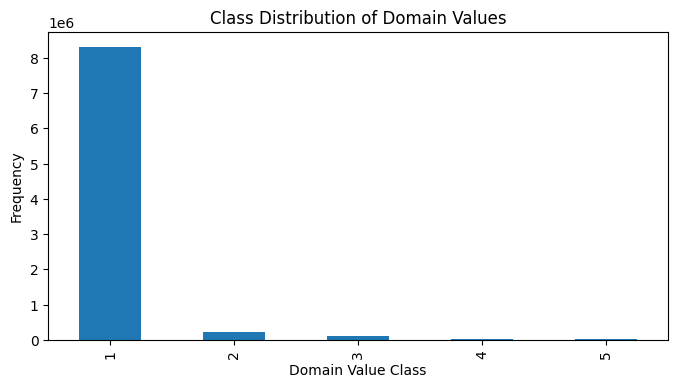

In [ ]:
df['category'].value_counts().plot(kind='bar', figsize=(8, 4))
plt.title('Class Distribution of Domain Values')
plt.xlabel('Domain Value Class')
plt.ylabel('Frequency')
plt.show()

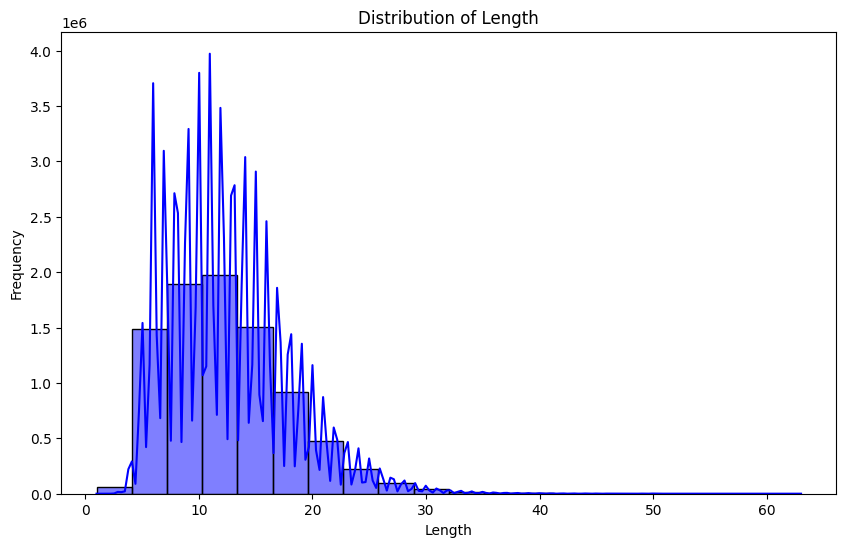

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['length'], bins=20, kde=True, color='blue')
plt.title('Distribution of Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

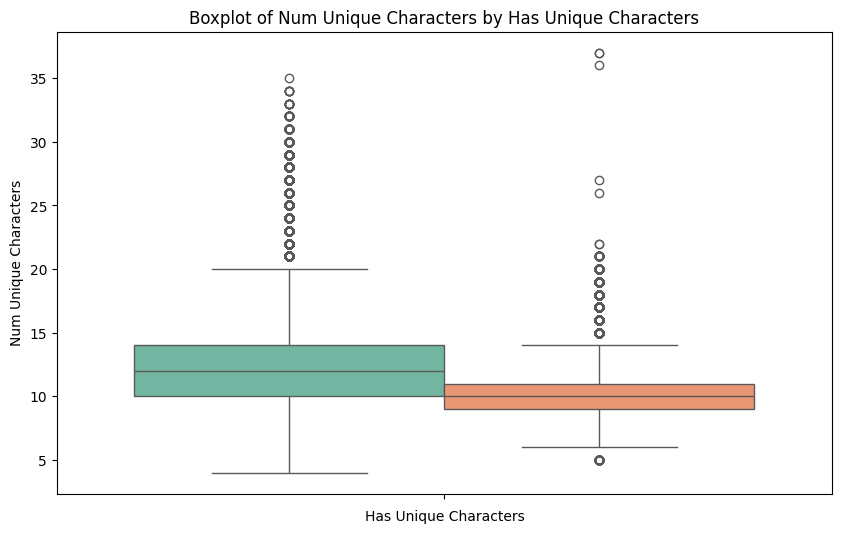

In [ ]:
# Boxplot of 'num_unique_characters' by 'has_unique_characters'
plt.figure(figsize=(10, 6))
sns.boxplot(hue='has_unique_characters', y='num_unique_characters', data=df, palette='Set2', legend=False)
plt.title('Boxplot of Num Unique Characters by Has Unique Characters')
plt.xlabel('Has Unique Characters')
plt.ylabel('Num Unique Characters')
plt.show()

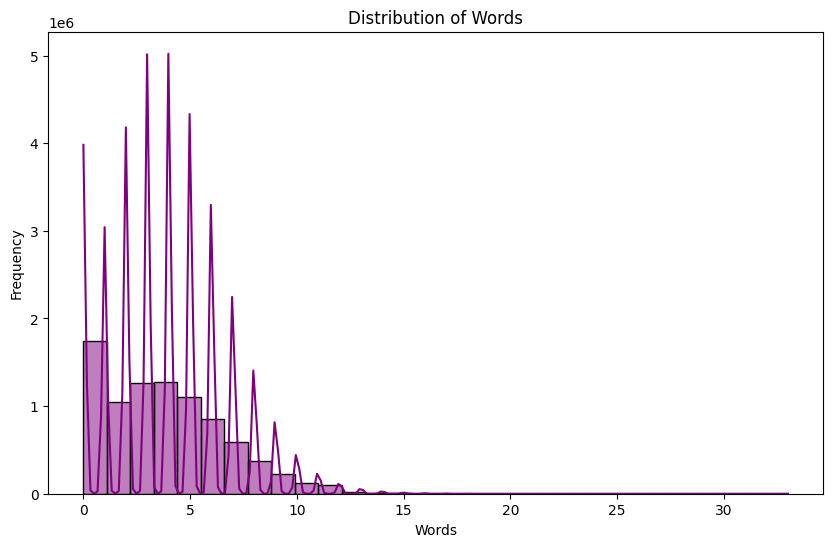

In [ ]:
# Distribution of 'words'
plt.figure(figsize=(10, 6))
sns.histplot(df['words'], bins=30, kde=True, color='purple')
plt.title('Distribution of Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

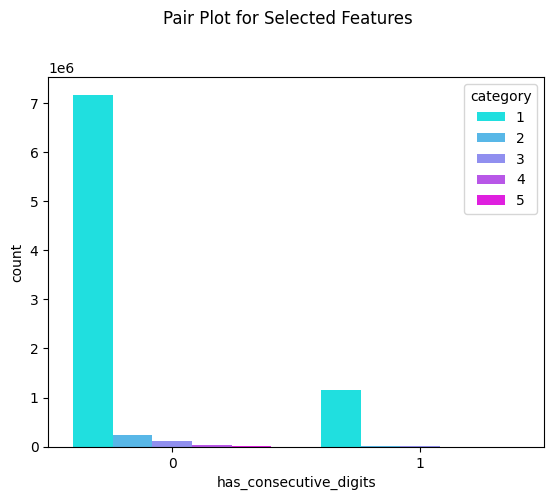

In [ ]:
# Pair Plot for Selected Columns
selected_columns = ['numerals', 'letters', 'special_char', 'length', 'words']
sns.countplot(x='has_consecutive_digits', hue='category', data=df, palette='cool')
plt.suptitle('Pair Plot for Selected Features', y=1.02)
plt.show()

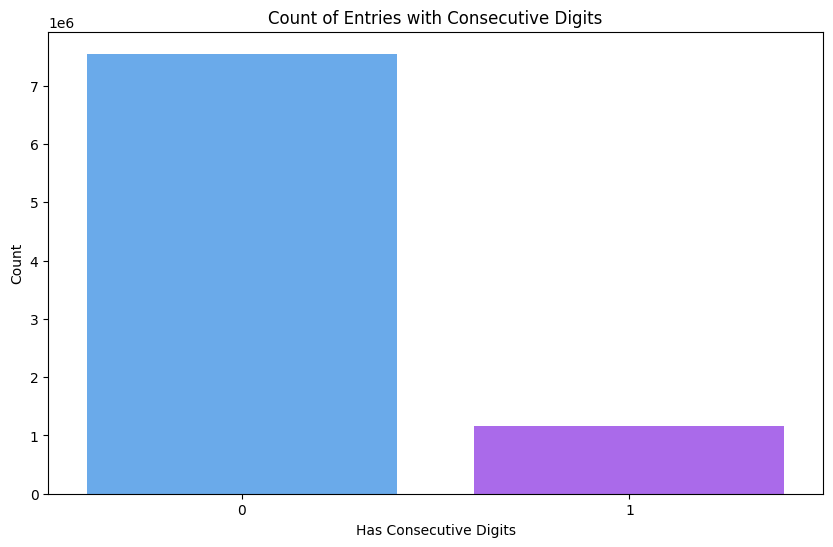

In [ ]:
# Count Plot for 'has_consecutive_digits'
plt.figure(figsize=(10, 6))
sns.countplot(x='has_consecutive_digits', hue='has_consecutive_digits', data=df, palette='cool', legend=False)
plt.title('Count of Entries with Consecutive Digits')
plt.xlabel('Has Consecutive Digits')
plt.ylabel('Count')
plt.show()

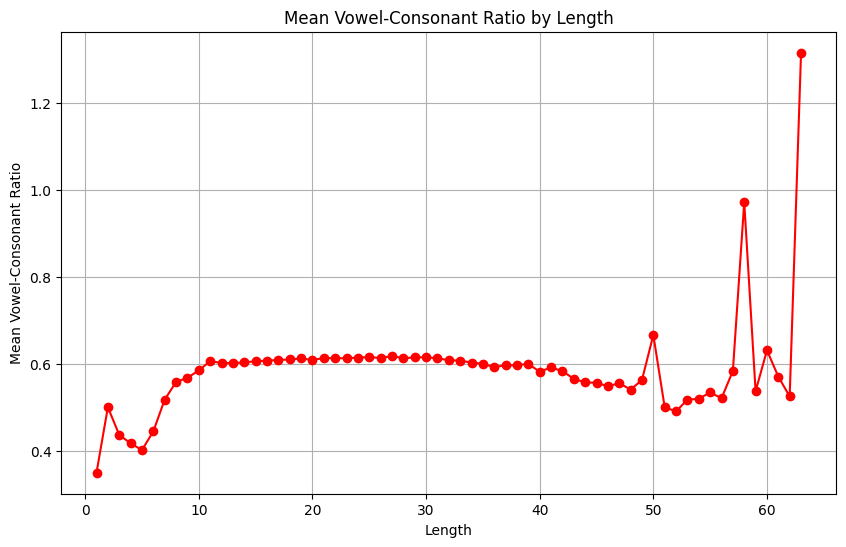

In [ ]:
# Line Plot of Mean 'vowel_consonant_ratio' by 'length'
mean_vcr_by_length = df.groupby('length')['vowel_consonant_ratio'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(mean_vcr_by_length['length'], mean_vcr_by_length['vowel_consonant_ratio'], marker='o', color='red')
plt.title('Mean Vowel-Consonant Ratio by Length')
plt.xlabel('Length')
plt.ylabel('Mean Vowel-Consonant Ratio')
plt.grid()
plt.show()

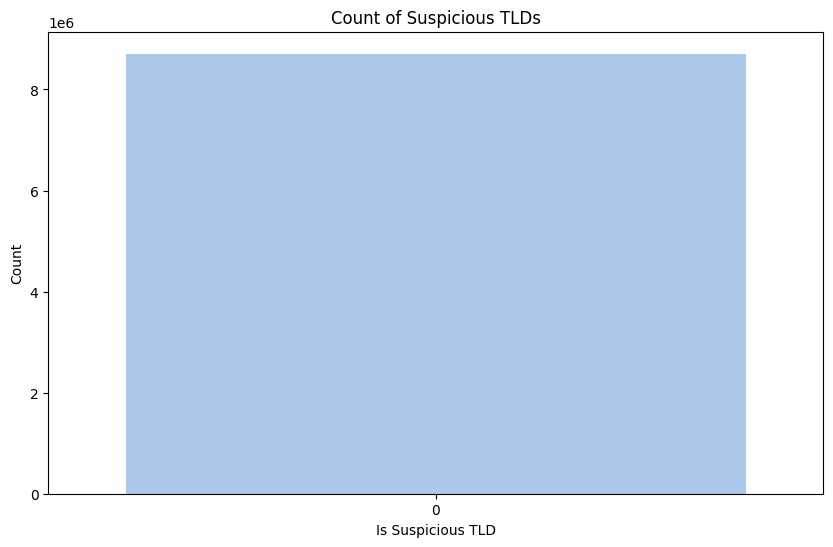

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_suspicious_tld', hue='is_suspicious_tld', data=df, palette='pastel', legend=False)
plt.title('Count of Suspicious TLDs')
plt.xlabel('Is Suspicious TLD')
plt.ylabel('Count')
plt.show()

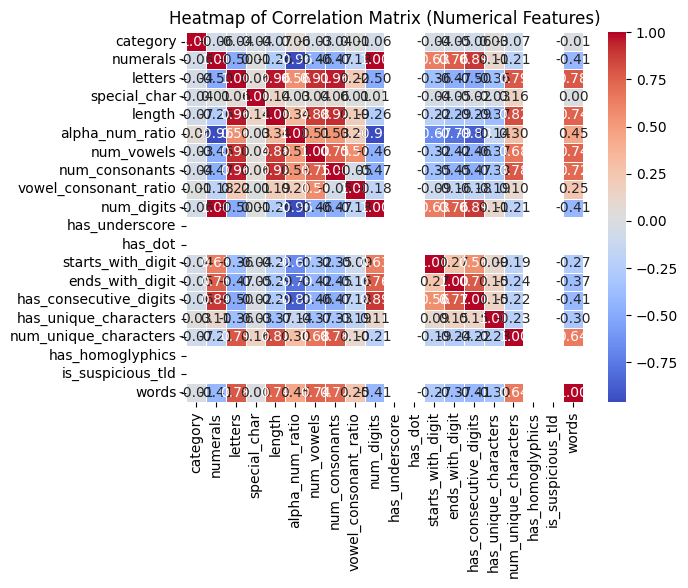

In [ ]:
# 7. Heat Map: Correlation Matrix
# Select only numerical columns
numerical_features = df.select_dtypes(include=[np.number])

# Compute the correlation matrix for numerical features
corr = numerical_features.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Correlation Matrix (Numerical Features)')
plt.show()

Data Preprocessing
- Data Cleaning

In [ ]:
#  check for null values
df.isnull().sum()

Domain                    0
category                  0
tld                       0
numerals                  0
letters                   0
special_char              0
length                    0
alpha_num_ratio           0
num_vowels                0
num_consonants            0
vowel_consonant_ratio     0
num_digits                0
has_hyphen                0
has_underscore            0
has_dot                   0
starts_with_digit         0
ends_with_digit           0
has_consecutive_digits    0
has_unique_characters     0
num_unique_characters     0
has_homoglyphics          0
is_suspicious_tld         0
words                     0
dtype: int64

In [ ]:
# Count the frequency of each TLD
tld_counts = df['tld'].value_counts()
print("TLD Frequency Distribution:")
print(tld_counts)

TLD Frequency Distribution:
tld
com                      8706539
au                          1082
br                           109
mx                            73
ar                            71
cn                            58
co                            32
es                            15
ng                            12
ph                            11
pe                             6
tw                             6
ve                             4
pl                             3
my                             3
ua                             2
pk                             2
sg                             2
ag                             2
georgetownhairspecial          1
gt                             1
ro                             1
uy                             1
gr                             1
bo                             1
vn                             1
Name: count, dtype: int64


In [ ]:
# Define a threshold for majority class
threshold = 0.5  # Example: Any TLD making up more than 50% of the dataset

# Calculate the threshold count
majority_threshold = len(df) * threshold

# Identify majority TLDs
majority_tlds = tld_counts[tld_counts > majority_threshold].index.tolist()
print("Majority TLDs:", majority_tlds)

Majority TLDs: ['com']


In [ ]:
# Separate majority and minority class rows
majority_class = df[df['tld'].isin(majority_tlds)]
minority_classes = df[~df['tld'].isin(majority_tlds)]

In [ ]:
# Downsample majority class
if len(majority_class) >= len(minority_classes):
    majority_downsampled = majority_class.sample(len(minority_classes), random_state=42)
else:
    raise ValueError("Majority class does not have enough data to downsample.")

# Combine balanced data
df_balanced = pd.concat([majority_downsampled, minority_classes])

# Verify the new class distribution
print("Class Distribution After Balancing:")
print(df_balanced['tld'].value_counts())

Class Distribution After Balancing:
tld
com                      1500
au                       1082
br                        109
mx                         73
ar                         71
cn                         58
co                         32
es                         15
ng                         12
ph                         11
pe                          6
tw                          6
ve                          4
pl                          3
my                          3
ua                          2
pk                          2
sg                          2
ag                          2
georgetownhairspecial       1
gt                          1
ro                          1
uy                          1
gr                          1
bo                          1
vn                          1
Name: count, dtype: int64


In [ ]:
df_balanced.describe()

,category,numerals,letters,special_char,length,alpha_num_ratio,num_vowels,num_consonants,vowel_consonant_ratio,num_digits,has_underscore,has_dot,starts_with_digit,ends_with_digit,has_consecutive_digits,has_unique_characters,num_unique_characters,has_homoglyphics,is_suspicious_tld,words
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.0,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.0,3000.000000
mean,1.885000,0.280333,10.874333,0.044333,11.199000,0.974405,5.838667,9.034000,0.674505,0.280333,0.0,0.0,0.030667,0.056333,0.063000,0.194333,11.559333,1.0,0.0,3.712667
std,1.084205,1.080186,5.581003,0.238859,5.385883,0.100259,2.483283,3.436197,0.259398,1.080186,0.0,0.0,0.172442,0.230603,0.243003,0.395753,2.356338,0.0,0.0,2.476318
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.250000,1.000000,2.000000,0.100000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,5.000000,1.0,0.0,0.000000
25%,1.000000,0.000000,7.000000,0.000000,7.000000,1.000000,4.000000,7.000000,0.500000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,10.000000,1.0,0.0,2.000000
50%,2.000000,0.000000,10.000000,0.000000,10.000000,1.000000,6.000000,9.000000,0.666667,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,11.000000,1.0,0.0,3.000000
75%,2.000000,0.000000,14.000000,0.000000,14.000000,1.000000,7.000000,11.000000,0.818182,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,13.000000,1.0,0.0,5.000000
max,5.000000,10.000000,39.000000,3.000000,39.000000,1.000000,17.000000,28.000000,3.000000,10.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,22.000000,1.0,0.0,14.000000


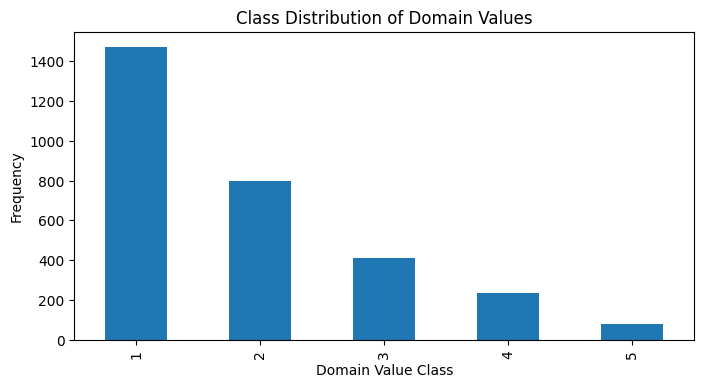

In [ ]:
df_balanced['category'].value_counts().plot(kind='bar', figsize=(8, 4))
plt.title('Class Distribution of Domain Values')
plt.xlabel('Domain Value Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df = df_balanced.copy()
df.head()

,Domain,category,tld,numerals,letters,special_char,length,alpha_num_ratio,num_vowels,num_consonants,...,has_underscore,has_dot,starts_with_digit,ends_with_digit,has_consecutive_digits,has_unique_characters,num_unique_characters,has_homoglyphics,is_suspicious_tld,words
6596107,ftgflower.com,1,com,0,9,0,9,1.000000,3,9,...,0,0,0,0,0,0,11,1,0,4
5884008,100toone.com,1,com,3,5,0,8,0.727273,4,4,...,0,0,1,0,1,0,9,1,0,4
5603028,ameriglide-winterhaven-fl.com,1,com,0,23,2,25,1.000000,10,16,...,0,0,0,0,0,0,18,1,0,8
4464756,irecte.com,1,com,0,6,0,6,1.000000,4,5,...,0,0,0,0,0,0,8,1,0,1
2316779,zxdfcv.com,1,com,0,6,0,6,1.000000,1,8,...,0,0,0,0,0,1,9,1,0,0


Data Preprocessing
- Pre-processing

In [ ]:
# label encoding
label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['category'])

In [ ]:
# scaling features

scaler = MinMaxScaler()
numerical_features = ['numerals',
                      'letters',
                      'special_char',
                      'length',
                      'alpha_num_ratio',
                      'num_vowels',
                      'num_consonants',
                      'vowel_consonant_ratio',
                      'num_digits',
                      'has_hyphen',
                      'has_underscore',
                      'has_dot',
                      'starts_with_digit',
                      'ends_with_digit',
                      'has_consecutive_digits',
                      'has_unique_characters',
                      'num_unique_characters',
                      'has_homoglyphics',
                      'is_suspicious_tld',
                      'words',]
df[numerical_features] = scaler.fit_transform(df[numerical_features])

Data Modelling

In [ ]:
# splitting traing & test data
x = df[numerical_features]
y = df['category_encoded']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

y_pred = dt_model.predict(x_test)

Evaluation Report of Decision Tree

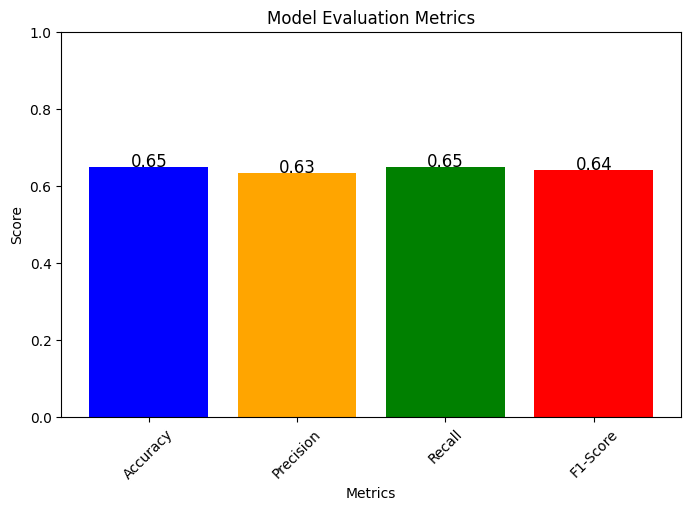

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(rotation=45)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', fontsize=12)
plt.show()

Confusion Matrix for Decision Tree

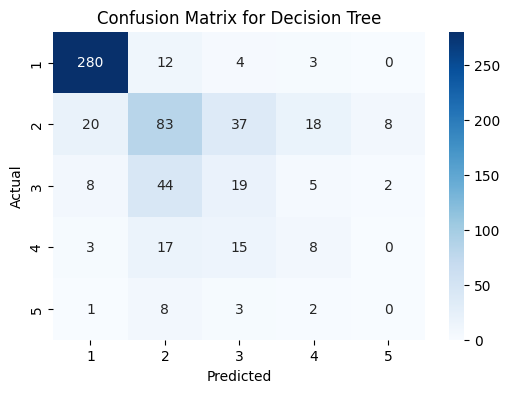

In [ ]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

# Make predictions
y_pred = rf_model.predict(x_test)

Evaluation Report of Random Forest Classifier

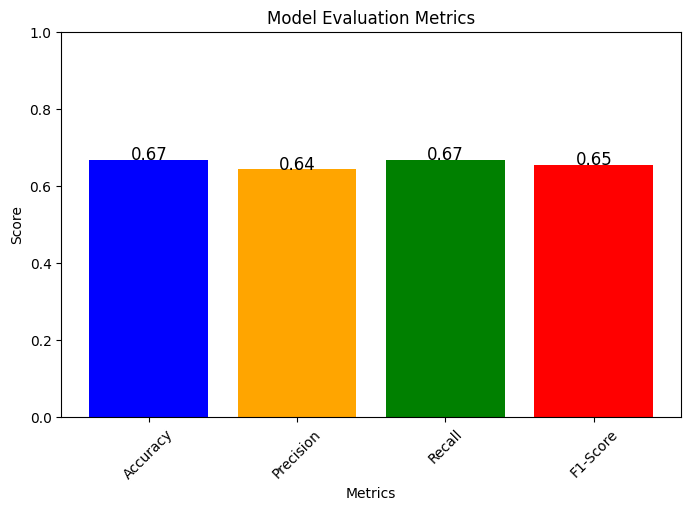

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(rotation=45)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', fontsize=12)
plt.show()

Confusion Matrix for Random Forest Classifier

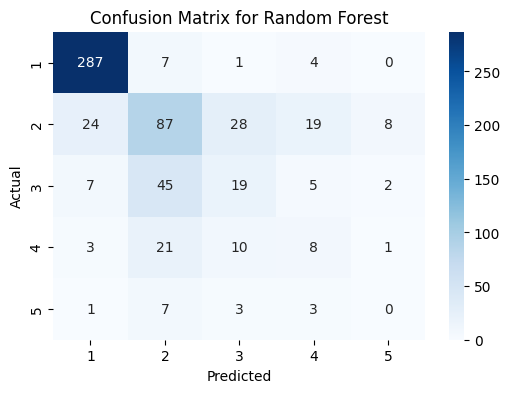

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression Classifier

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)

y_pred = lr_model.predict(x_test)

Evaluation Report of Logistic Regression

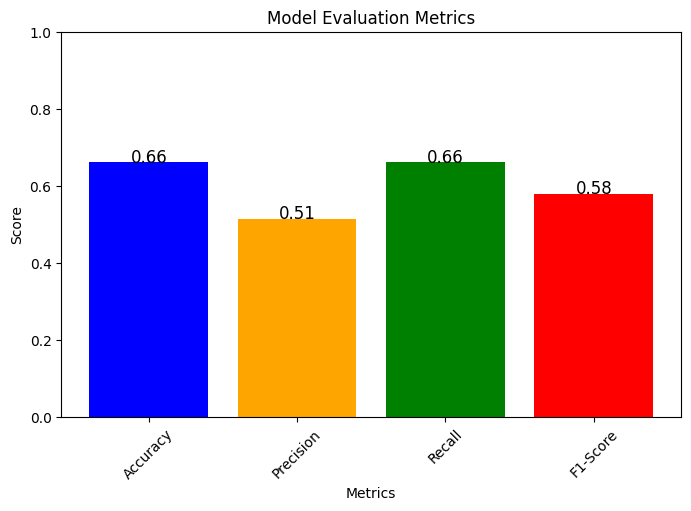

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(rotation=45)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', fontsize=12)
plt.show()

Confusion Matrix for Logistic Regression

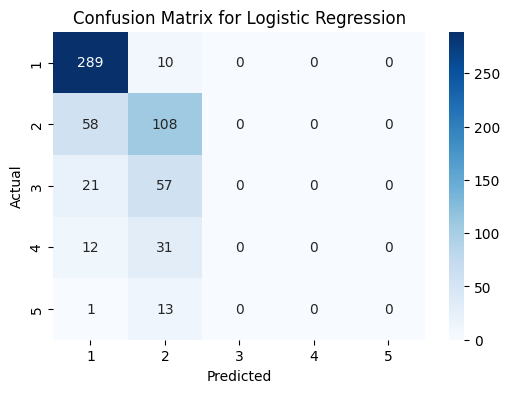

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Parameter Tuning - Decision Tree

In [ ]:
# Parameter tuning for Decision Tree
dt_param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    dt_param_grid, cv=3, n_iter=10, n_jobs=-1, random_state=42,
)
dt_random_search.fit(x_train, y_train)

print("Best Parameters for Decision Tree:", dt_random_search.best_params_)

Best Parameters for Decision Tree: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 20, 'criterion': 'entropy'}


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=None, min_samples_leaf=2, min_samples_split=5)
dt_model.fit(x_train, y_train)

y_pred = dt_model.predict(x_test)

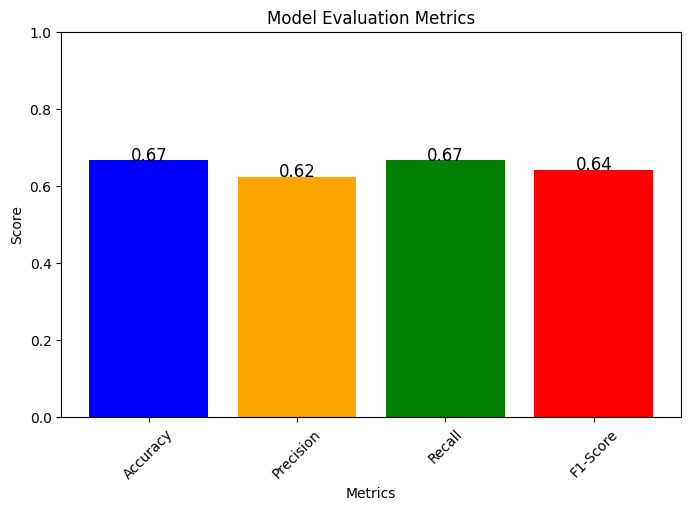

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(rotation=45)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', fontsize=12)
plt.show()

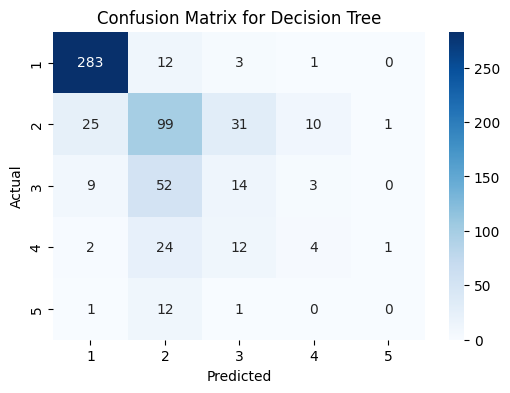

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Parameter Tuning - Random Forest

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy', 'log_loss']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, n_jobs=-1)

rf_grid.fit(x_train, y_train)

print("Best Parameters for Random Forest:", rf_grid.best_params_)

Best Parameters for Random Forest: {'criterion': 'entropy', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/ma/core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
rf_tuned_model = RandomForestClassifier(random_state=42, n_estimators=100, criterion='entropy', min_samples_split=10, min_samples_leaf=1, max_depth=30, max_features='sqrt')
rf_tuned_model.fit(x_train, y_train)

y_pred = rf_tuned_model.predict(x_test)

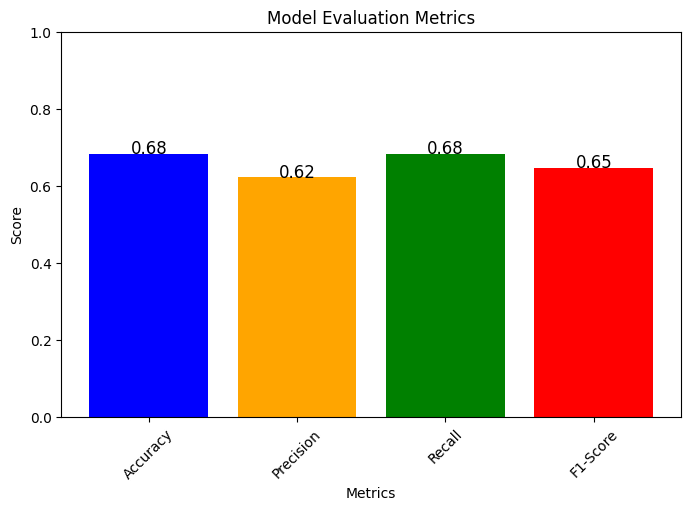

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(rotation=45)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', fontsize=12)
plt.show()

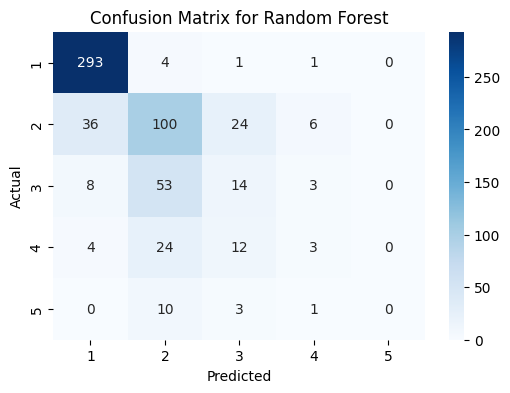

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Parameter Tuning - Logistic Regression

In [ ]:
lr_param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs'], 'max_iter': [1000]},
    {'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear'], 'max_iter': [1000]},
    {'penalty': ['l1', 'l2', 'elasticnet'], 'C': [0.01, 0.1, 1, 10], 'solver': ['saga'], 'max_iter': [1000]},
]

lr_random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=3,
    n_iter=5,
    n_jobs=-1,
    random_state=42
)

lr_random_search.fit(x_train, y_train)

print("Best Parameters for Logistic Regression:", lr_random_search.best_params_)

Best Parameters for Logistic Regression: {'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 1000, 'C': 100}


In [ ]:
lr_tuned_model = LogisticRegression(random_state=42, C=100, penalty='l1', solver='liblinear', max_iter=1000)
lr_tuned_model.fit(x_train, y_train)

y_pred = lr_tuned_model.predict(x_test)

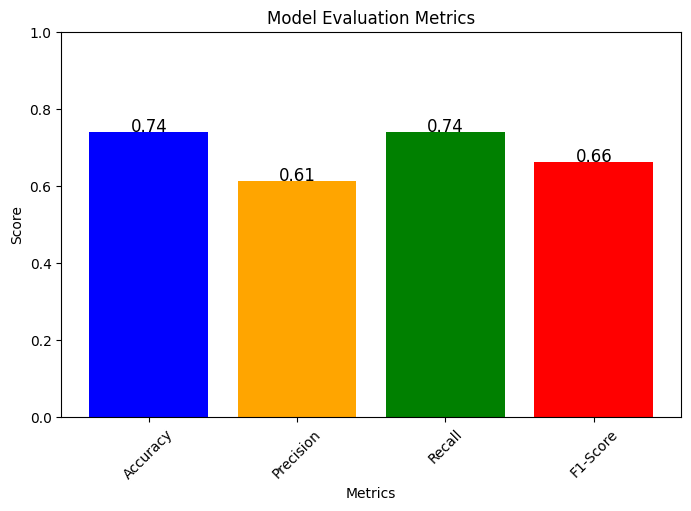

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, scores, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.xticks(rotation=45)
for i, score in enumerate(scores):
    plt.text(i, score, f'{score:.2f}', ha='center', fontsize=12)
plt.show()

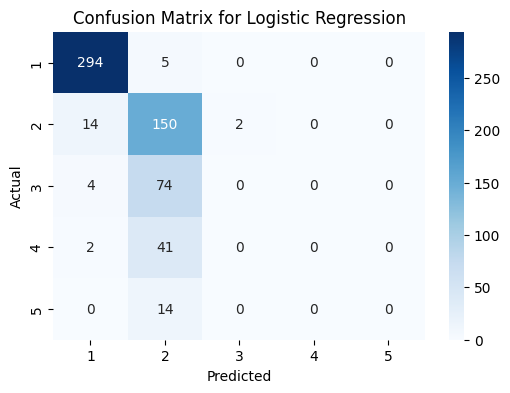

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

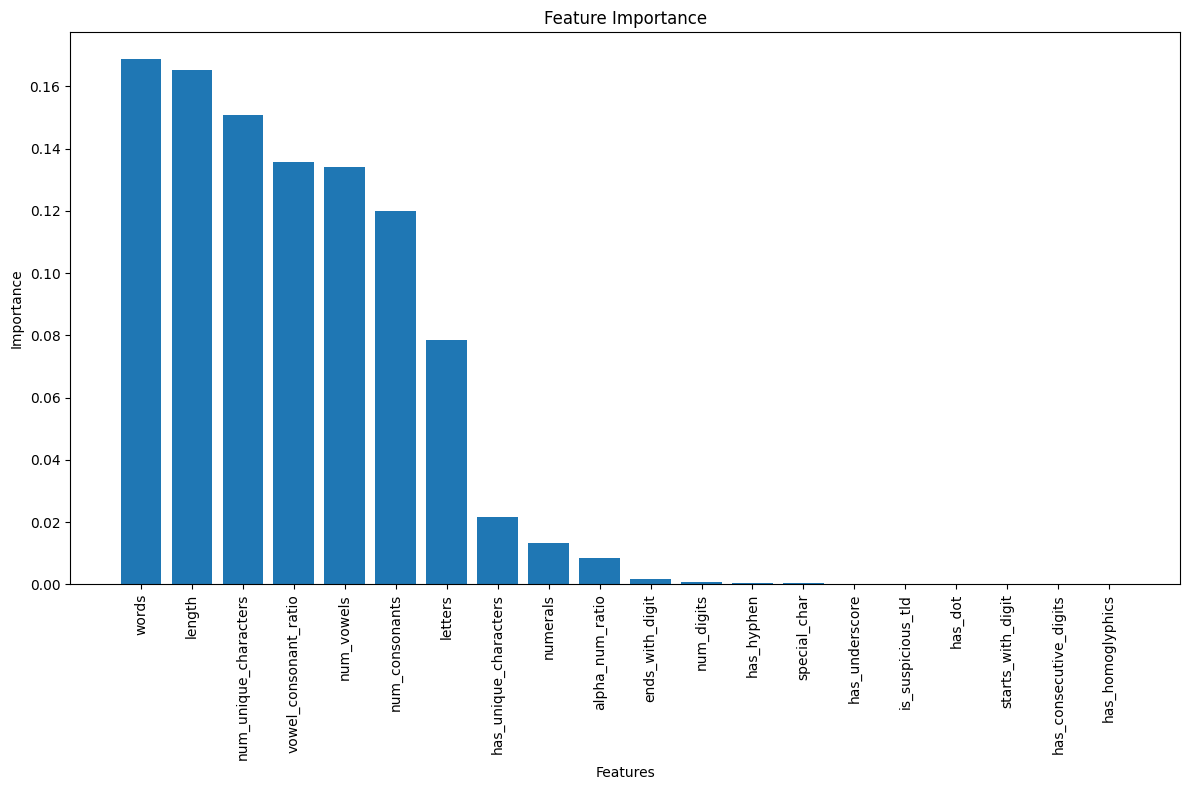

In [ ]:
X = df['category']
Y = df.drop(columns=['category', 'category_encoded', 'Domain', 'tld'])

X_train, X_test, Y_train, Y_test = train_test_split(Y, X, test_size=0.2, random_state=42)

DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train, Y_train)

Y_pred = DT.predict(X_test)

importances = DT.feature_importances_
feature_names = Y.columns

# Plot feature importance
sorted_indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 8))
plt.bar(range(len(importances)), importances[sorted_indices], align='center')
plt.xticks(range(len(importances)), feature_names[sorted_indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()